Regressione LASSO

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, LassoCV, LinearRegression

In [2]:
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

display(X)
display(y)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

In [3]:
# come prima cosa dobbiamo scalare i dati

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
display(X_scaled)

array([[ 0.80050009,  1.06548848,  1.29708846, ..., -0.05449919,
         0.41853093, -0.37098854],
       [-0.03956713, -0.93853666, -1.08218016, ..., -0.83030083,
        -1.43658851, -1.93847913],
       [ 1.79330681,  1.06548848,  0.93453324, ..., -0.05449919,
         0.06015558, -0.54515416],
       ...,
       [ 0.87686984,  1.06548848, -0.33441002, ..., -0.23293356,
        -0.98564884,  0.32567395],
       [-0.9560041 , -0.93853666,  0.82123474, ...,  0.55838411,
         0.93616291, -0.54515416],
       [-0.9560041 , -0.93853666, -1.53537419, ..., -0.83030083,
        -0.08875225,  0.06442552]], shape=(442, 10))

In [4]:
# come baseline andiamo ad allenare una regresione lineare

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)
y_pred_lin = lin_reg.predict(X_scaled)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

print(f"MSE:\t{mse_lin}\nR2:{r2_lin}")

MSE:	2859.6963475867506
R2:0.5177484222203498


In [5]:
# valutazione della regressione LASSO

r2_lasso = []
mse_lasso = []
alphas = np.logspace(-4, 10, 100)

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_scaled, y)
    y_pred = lasso.predict(X_scaled)
    mse_lasso.append(mean_squared_error(y, y_pred))
    r2_lasso.append(r2_score(y, y_pred))

# andiamo a mettere il risultato in un dataframe
results = pd.DataFrame({"alphas":alphas, "MSE":mse_lasso, "R2":r2_lasso})
display(results)


,alphas,MSE,R2
0,1.000000e-04,2859.696352,0.517748
1,1.384886e-04,2859.696356,0.517748
2,1.917910e-04,2859.696365,0.517748
3,2.656088e-04,2859.696380,0.517748
4,3.678380e-04,2859.696410,0.517748
...,...,...,...
95,2.718588e+09,5929.884897,0.000000
96,3.764936e+09,5929.884897,0.000000
97,5.214008e+09,5929.884897,0.000000
98,7.220809e+09,5929.884897,0.000000


In [6]:
# indice minimo del valore mse e vedere a quale alpha corrisponde e quale valore ha

best_idx_man = np.argmin(mse_lasso)
best_alpha_man = alphas[best_idx_man]
best_mse_man = mse_lasso[best_idx_man]
best_r2_man = r2_lasso[best_idx_man]

print(f"Alpha LASSO:\t{best_alpha_man:.4f}\nMSE:\t{best_mse_man:.4f}\nR2:\t{best_r2_man:.4f}")

Alpha LASSO:	0.0001
MSE:	2859.6964
R2:	0.5177


In [7]:
# regressione LASSO con cross-validation

alphas_cv = alphas
lasso_cv = LassoCV(alphas=alphas_cv, cv = 5, random_state=42, max_iter=1000)
lasso_cv.fit(X_scaled, y)

print(f"alpha LASSOCV:\t{lasso_cv.alpha_}")

y_pred_cv = lasso_cv.predict(X_scaled)
mse_cv = mean_squared_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

print(f"MSE LASSOCV:\t{mse_cv}\nR2:\t{r2_cv}")

alpha LASSOCV:	0.06734150657750822
MSE LASSOCV:	2861.5174690008103
R2:	0.5174413131540324


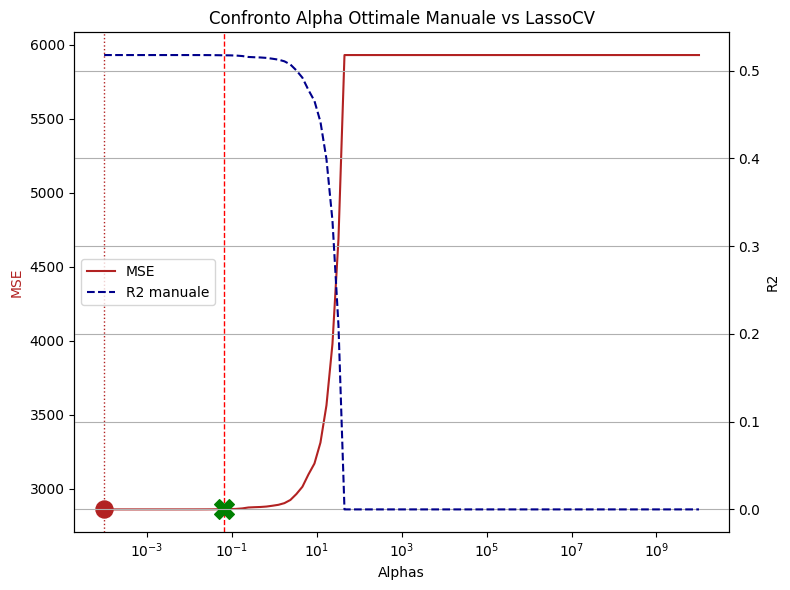

In [11]:
# plot di entrambi i valori di alpha trovati

fig, ax1 = plt.subplots(figsize = (8,6))
l1 = ax1.plot(alphas, mse_lasso, "-", color="firebrick", label = "MSE")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE", color="firebrick")

# scatter plot degli alpha manuali
ax1.scatter(best_alpha_man, best_mse_man, color="firebrick", s=150, zorder=5, label=f"Alpha ottimale manuale")
ax1.axvline(best_alpha_man, color="firebrick", linestyle=":", linewidth=1)

# scatter plot dell'alpha trovato con la cross validation
ax1.scatter(lasso_cv.alpha_, mean_squared_error(y, lasso_cv.predict(X_scaled)),
            color = "green", marker = "X", s=200, zorder=5,
            label = f"alpha Ridge={lasso_cv.alpha_:.4f}")
ax1.axvline(lasso_cv.alpha_, color="red", linestyle="--", linewidth=1)

ax2 = ax1.twinx()
l2 = ax2.plot(alphas, r2_lasso, "--", color="darkblue", label="R2 manuale")
ax2.set_ylabel("R2")

plt.title(f"Confronto Alpha Ottimale Manuale vs LassoCV")
plt.grid()

lines = l1+l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc = "center left")

plt.tight_layout()
plt.show()